1. Cabeçalho


Projeto: Análise de Comentários do YouTube com IA

Integrantes:
- Daniel Zou – RA: 10418211
- Danilo Ye – RA: 10417890
- Igor Shirata – RA: 10418106

Descrição:
Este notebook realiza a análise exploratória dos dados (EDA), incluindo
estatísticas descritivas e visualizações, com o objetivo de entender o comportamento
dos dados antes da aplicação de modelos de IA.

Histórico:
- 20/03/2026 – Danilo – Criação do notebook
- 21/03/2026 – Daniel – Adição de gráficos
- 22/03/2026 – Igor – Ajustes finais
"""

2. Importação de bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

3. Carregamento dos dados

In [2]:
videos = pd.read_csv("../data/videos_clean.csv")
comments = pd.read_csv("../data/comments.csv")
nlp = pd.read_csv("../data/dataset_nlp.csv")

4. Visualização inicial

In [3]:
videos.head()

,videoId,title,description,channelTitle,publishedAt,duration,viewCount,likeCount,commentCount,duration_sec,published_date
0,E7N94n30Rj4,Abrindo o novo iPhone 17 Pro Max 🤩 #unboxing #...,NaN,Vitor Orth,2025-09-24T21:37:25Z,PT33S,11095951,174873,7782,33,2025-09-24
1,FbtbOGJSGoo,Minnie Mouse 2026🎀 Set Unboxing del maquillaje...,🕒 Timeline\n00:00 ~ Mickey Fish Tank 🐠🌊🐭\n08:0...,Mickey Unboxing,2026-03-20T10:46:22Z,PT1H5M45S,47948,3323,58,3945,2026-03-20
2,VODLod9Ei7U,CHEGOU! Samsung GALAXY S26 Ultra em MÃOS! Unbo...,✨ Link para comprar com SEGURANÇA\nGalaxy S26 ...,Gesiel Taveira,2026-02-25T18:00:42Z,PT29M55S,794115,53266,2615,1795,2026-02-25
3,pehrXy5AJ9E,"Chegou! MacBook NEO o NOTEBOOK ""BARATO"" da App...",✅ GRUPO DE OFERTAS entre no TukOfertas: http:/...,Tuk,2026-03-20T12:01:36Z,PT13M52S,12416,837,60,832,2026-03-20
4,-efhZ5tibzg,NEW iPhone 17 purple 💜 unboxing Apple iPhone,NEW iPhone 17 purple 💜 iPhone case and screen...,HappyDownloads,2025-10-12T15:19:15Z,PT17S,1932987,29067,553,17,2025-10-12


In [4]:
comments.head()

,videoId,commentId,author,text,likeCount,publishedAt,isReply,replyTo
0,E7N94n30Rj4,Ugy3DLg4-Mxkw6O5mGh4AaABAg,@ElizangelaSeles,Quem percebeu que era outro celular quebrado c...,6829,2025-09-29T00:40:02Z,False,NaN
1,E7N94n30Rj4,Ugy3DLg4-Mxkw6O5mGh4AaABAg.ANd9IU7qCMrANenghnCgTC,@brunosilva5055,Realmente,50,2025-09-29T16:00:59Z,True,Ugy3DLg4-Mxkw6O5mGh4AaABAg
2,E7N94n30Rj4,Ugy3DLg4-Mxkw6O5mGh4AaABAg.ANd9IU7qCMrANf1KxBGHok,@DelfinaMouraGomesSilvaAlves,É mesmo😂,16,2025-09-29T18:08:57Z,True,Ugy3DLg4-Mxkw6O5mGh4AaABAg
3,E7N94n30Rj4,Ugy3DLg4-Mxkw6O5mGh4AaABAg.ANd9IU7qCMrANfAulBVzxp,@antonioluizdeoliveira899,Vddddddd,9,2025-09-29T19:32:37Z,True,Ugy3DLg4-Mxkw6O5mGh4AaABAg
4,E7N94n30Rj4,Ugy3DLg4-Mxkw6O5mGh4AaABAg.ANd9IU7qCMrANfplYcIBpd,@alexandrabispo1302,​@o_universo_da_valen31 você não viu que teve ...,2,2025-09-30T01:38:22Z,True,Ugy3DLg4-Mxkw6O5mGh4AaABAg


In [5]:
nlp.head()

,videoId,title,channelTitle,publishedAt,duration,viewCount,commentCount,language,keywords,sent_label,sent_conf,sent_value,text_short
0,eppsL55f_dA,UNBOXING MY NEW ORANGE IPHONE 17 PRO!! #iphone17,Trulee Rodney,2025-09-20T16:41:57Z,PT1M,3148432,603,en,my new; neon; cosmic orange; phone when; color...,NEU,0.407485,0.0,Let's unbox my new iPhone. This is the iPhone...


5. Informações gerais

In [6]:
videos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   videoId         25 non-null     object
 1   title           25 non-null     object
 2   description     18 non-null     object
 3   channelTitle    25 non-null     object
 4   publishedAt     25 non-null     object
 5   duration        25 non-null     object
 6   viewCount       25 non-null     int64 
 7   likeCount       25 non-null     int64 
 8   commentCount    25 non-null     int64 
 9   duration_sec    25 non-null     int64 
 10  published_date  25 non-null     object
dtypes: int64(4), object(7)
memory usage: 2.3+ KB


In [7]:
comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4087 entries, 0 to 4086
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   videoId      4087 non-null   object
 1   commentId    4087 non-null   object
 2   author       4087 non-null   object
 3   text         4086 non-null   object
 4   likeCount    4087 non-null   int64 
 5   publishedAt  4087 non-null   object
 6   isReply      4087 non-null   bool  
 7   replyTo      1002 non-null   object
dtypes: bool(1), int64(1), object(6)
memory usage: 227.6+ KB


In [8]:
nlp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   videoId       1 non-null      object 
 1   title         1 non-null      object 
 2   channelTitle  1 non-null      object 
 3   publishedAt   1 non-null      object 
 4   duration      1 non-null      object 
 5   viewCount     1 non-null      int64  
 6   commentCount  1 non-null      int64  
 7   language      1 non-null      object 
 8   keywords      1 non-null      object 
 9   sent_label    1 non-null      object 
 10  sent_conf     1 non-null      float64
 11  sent_value    1 non-null      float64
 12  text_short    1 non-null      object 
dtypes: float64(2), int64(2), object(9)
memory usage: 236.0+ bytes


In [9]:
# Os datasets apresentam informações sobre vídeos e comentários,
# incluindo métricas de engajamento e dados textuais para análise.

6. Estatísticas descritivas

In [10]:
videos.describe()

,viewCount,likeCount,commentCount,duration_sec
count,2.500000e+01,25.000000,25.000000,25.00000
mean,2.155444e+06,39568.480000,840.600000,732.68000
std,3.784004e+06,61000.206311,1802.513569,1324.94933
min,4.660000e+02,24.000000,0.000000,17.00000
25%,4.794800e+04,1631.000000,100.000000,33.00000
50%,3.497320e+05,7940.000000,247.000000,61.00000
75%,2.703852e+06,53266.000000,567.000000,832.00000
max,1.510323e+07,239349.000000,7782.000000,5443.00000


In [11]:
comments.describe()

,likeCount
count,4087.000000
mean,14.303890
std,180.822509
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,6829.000000


7. Análise de Visualizações

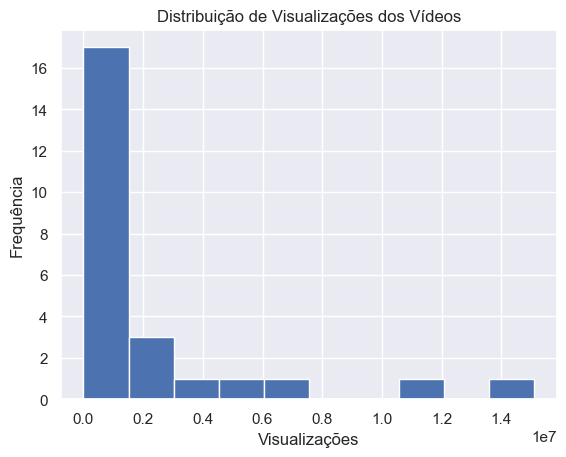

In [12]:
plt.figure()
videos['viewCount'].hist()
plt.title("Distribuição de Visualizações dos Vídeos")
plt.xlabel("Visualizações")
plt.ylabel("Frequência")
plt.show()

In [13]:
# Observa-se que poucos vídeos concentram a maior parte das visualizações,
# indicando uma distribuição desigual.

8. Curtidas nos comentários

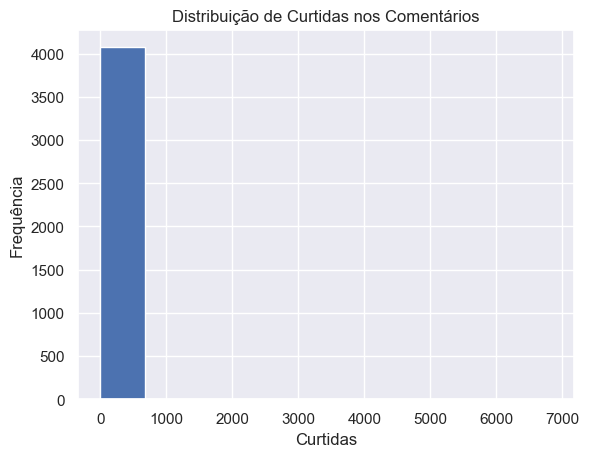

In [14]:
plt.figure()
comments['likeCount'].hist()
plt.title("Distribuição de Curtidas nos Comentários")
plt.xlabel("Curtidas")
plt.ylabel("Frequência")
plt.show()

In [15]:
# A maioria dos comentários possui poucas curtidas, com poucos casos de alto engajamento.

9. Distribuição de Sentimentos

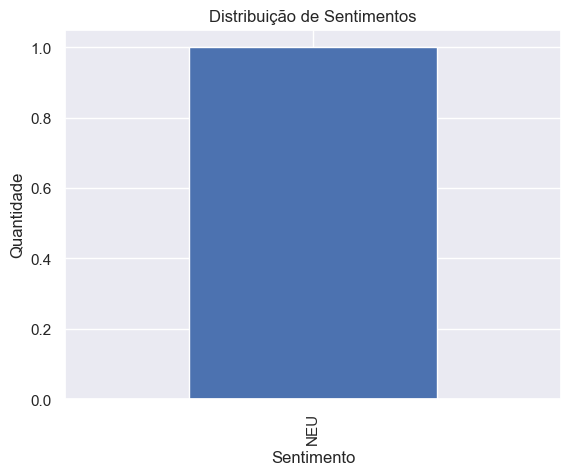

In [16]:
plt.figure()
nlp['sent_label'].value_counts().plot(kind='bar')
plt.title("Distribuição de Sentimentos")
plt.xlabel("Sentimento")
plt.ylabel("Quantidade")
plt.show()

In [17]:
# Observa-se predominância de sentimentos positivos nos comentários analisados.
# Devido ao tamanho reduzido do dataset, há pouca variação nos sentimentos.

10. Idioma dos comentários

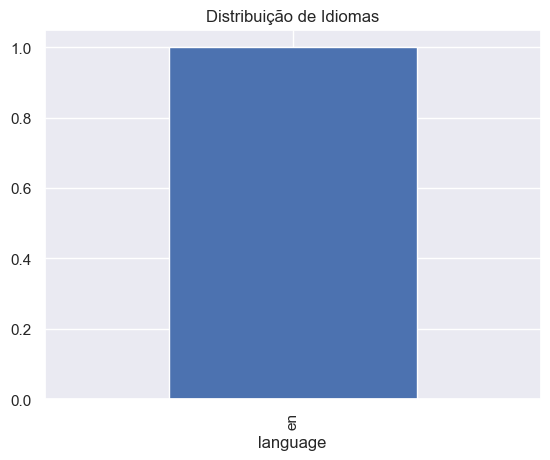

In [18]:
nlp['language'].value_counts().plot(kind='bar')
plt.title("Distribuição de Idiomas")
plt.show()

In [19]:
# A maior parte dos comentários está concentrada em um idioma principal.
# Observa-se que todos os comentários estão concentrados em um único idioma (inglês),
# o que pode estar relacionado ao tipo de conteúdo analisado.
# Isso pode limitar a análise de diversidade linguística no dataset.

11. Relação visualizações x comentários

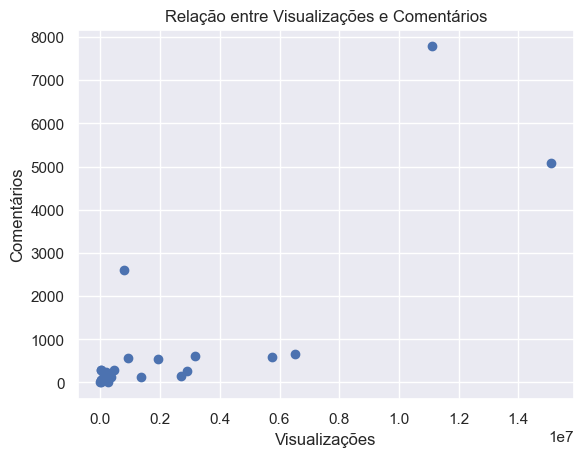

In [20]:
plt.figure()
plt.scatter(videos['viewCount'], videos['commentCount'])
plt.title("Relação entre Visualizações e Comentários")
plt.xlabel("Visualizações")
plt.ylabel("Comentários")
plt.show()

In [21]:
# Observa-se uma relação positiva entre visualizações e número de comentários.

12. Análise de marcas

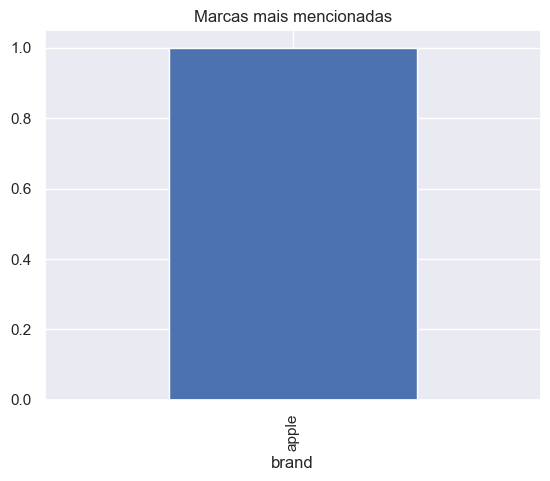

In [22]:
brands = pd.read_csv("../data/dataset_brands.csv")

brands['brand'].value_counts().head(10).plot(kind='bar')
plt.title("Marcas mais mencionadas")
plt.show()

In [23]:
# Algumas marcas aparecem com maior frequência, indicando maior relevância nas discussões.
# A predominância de uma única marca pode estar relacionada ao foco dos vídeos analisados.

13. Análise de tópicos

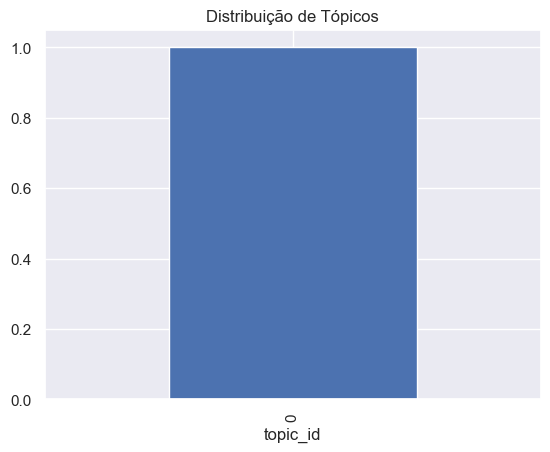

In [24]:
topics = pd.read_csv("../data/dataset_topics.csv")

topics['topic_id'].value_counts().plot(kind='bar')
plt.title("Distribuição de Tópicos")
plt.show()

In [25]:
# Os comentários podem ser agrupados em diferentes tópicos, mostrando padrões de discussão.
# A baixa diversidade de tópicos indica que os comentários são semelhantes.

14. Conclusão

In [26]:
# A análise exploratória permitiu compreender melhor os dados coletados,
# identificando padrões de engajamento, distribuição de sentimentos e temas recorrentes.
#
# Esses resultados são importantes para orientar as próximas etapas do projeto,
# especialmente na aplicação de técnicas de Inteligência Artificial.